# Prostate MRI PI-RADS Model Training

This notebook trains the model used by the Gradio app in this repository.

## Plain-English Purpose

The app estimates a PI-RADS-style prostate cancer risk score from prostate MRI images. PI-RADS is a 1-to-5 scale used by radiologists: 1 means very low suspicion and 5 means very high suspicion.

This notebook shows how the model is trained from paired MRI image slices and PI-RADS labels.

## Data Source

The data source is the **NYU fastMRI prostate MRI dataset**:

```text
https://fastmri.med.nyu.edu/
```

The fastMRI site describes the prostate dataset as **312 prostate MRI exams acquired on 3 Tesla scanners**, including axial T2-weighted and axial diffusion-weighted images.

## How To Obtain The Data

The raw NYU fastMRI data is **not included in this GitHub repository**. To experiment with the data yourself:

1. Go to `https://fastmri.med.nyu.edu/`.
2. Read the dataset description and the fastMRI Dataset Sharing Agreement.
3. Apply for access using the online application form.
4. Use your own approved download link after acceptance.
5. Do not share the data, patient images, labels, or download links through GitHub.

NYU's access language states that the data is for internal research or educational use under the Dataset Sharing Agreement and may not be redistributed without permission. That is why this repository contains code, documentation, and a trained demo checkpoint, but not raw fastMRI data.

## Local Data Layout For Rerunning Training

After approved access, place your local copy in one of these layouts:

```text
data/raw/NYU/DICOMS
data/raw/NYU/labels
```

or set an environment variable before running the notebook:

```text
FASTMRI_NYU_ROOT=/path/to/NYU
```

The app itself can run with the included checkpoint and does not need the raw training dataset.

## What The Notebook Does

- loads prostate MRI image folders and PI-RADS label CSVs from an authorized local fastMRI dataset copy,
- builds matched image triplets using T2, ADC, and BVAL/B1500 views of the same slice,
- trains a VAE-style image model with a PI-RADS classifier,
- evaluates the model on held-out patients,
- saves the trained checkpoint used by `app/app.py`.



In [18]:
from __future__ import annotations

import importlib.util
import math
import os
import random
import sys
import warnings
from functools import lru_cache
from pathlib import Path

# Keep the dependency gate simple so the notebook fails early with a clear message.
REQUIRED_MODULES = {
    "pydicom": "pydicom",
    "sklearn": "scikit-learn",
}
missing_modules = [pkg for mod, pkg in REQUIRED_MODULES.items() if importlib.util.find_spec(mod) is None]
if missing_modules:
    raise ModuleNotFoundError(
        "Missing notebook dependencies: " + ", ".join(missing_modules) + ". Install them with: "
        + f"{sys.executable} -m pip install " + " ".join(missing_modules)
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
from pydicom.uid import UID
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


def compression_plugin_status() -> dict[str, bool]:
    # These optional packages let pydicom decode JPEG-compressed pixel data.
    return {
        'gdcm': importlib.util.find_spec('gdcm') is not None,
        'pylibjpeg': importlib.util.find_spec('pylibjpeg') is not None,
        'pylibjpeg_libjpeg': importlib.util.find_spec('pylibjpeg_libjpeg') is not None,
    }


def compressed_dicom_requires_plugins(dicoms_root: Path) -> tuple[bool, str | None, str | None]:
    # Scan a few files up front so the notebook can fail early with a useful install command.
    for file_path in sorted(dicoms_root.rglob('*')):
        if not file_path.is_file() or file_path.name.startswith('.'):
            continue
        try:
            ds = pydicom.dcmread(str(file_path), stop_before_pixels=True, force=True)
            ts = getattr(getattr(ds, 'file_meta', None), 'TransferSyntaxUID', None)
            if ts is None:
                continue
            ts_uid = UID(str(ts))
            return bool(ts_uid.is_compressed), str(ts_uid), ts_uid.name
        except Exception:
            continue
    return False, None, None



def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "app" / "app.py").exists() and (candidate / "src" / "prostate_pirads_model.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing app/app.py and src/prostate_pirads_model.py.")


def find_nyu_root(project_root: Path) -> Path:
    env_root = os.environ.get("FASTMRI_NYU_ROOT")
    if env_root:
        root = Path(env_root).expanduser().resolve()
        if (root / "DICOMS").exists() and (root / "labels").exists():
            return root
        raise FileNotFoundError("FASTMRI_NYU_ROOT must contain DICOMS/ and labels/ folders.")

    candidates = [
        project_root / "data" / "raw" / "NYU",
        project_root.parent / "NYU",
        project_root.parent.parent / "NYU",
    ]
    for root in candidates:
        if (root / "DICOMS").exists() and (root / "labels").exists():
            return root
    raise FileNotFoundError(
        "Could not locate the NYU fastMRI data. Set FASTMRI_NYU_ROOT=/path/to/NYU "
        "or place DICOMS/ and labels/ under data/raw/NYU/."
    )


PROJECT_ROOT = find_project_root()
NYU_ROOT = find_nyu_root(PROJECT_ROOT)
DICOMS_ROOT = NYU_ROOT / "DICOMS"
LABEL_ROOT = NYU_ROOT / "labels"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "training"
PROJECT_MODEL_PATH = PROJECT_ROOT / "app" / "model" / "prostate_pirads_vae.pt"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PROJECT_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from prostate_pirads_model import (
    PIRADS_CLASS_NAMES,
    PhysicsAwareSliceVAE,
    build_checkpoint_payload,
    physics_aware_vae_loss,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compressed_sample_found, sample_ts_uid, sample_ts_name = compressed_dicom_requires_plugins(DICOMS_ROOT)
plugin_status = compression_plugin_status()
has_decoder = plugin_status['gdcm'] or (plugin_status['pylibjpeg'] and plugin_status['pylibjpeg_libjpeg'])
if compressed_sample_found and not has_decoder:
    raise ModuleNotFoundError(
        'This dataset uses compressed DICOM pixel data '
        + f'({sample_ts_name} / {sample_ts_uid}), but no compatible decoder plugin is installed. '
        + 'Install one of these before running the notebook: '
        + f"{sys.executable} -m pip install pylibjpeg pylibjpeg-libjpeg "
        + 'or '
        + f"{sys.executable} -m pip install gdcm"
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"NYU data root: {NYU_ROOT}")
print(f"DICOMS root  : {DICOMS_ROOT}")
print(f"Labels root  : {LABEL_ROOT}")
print(f"Model path   : {PROJECT_MODEL_PATH}")
print(f"Output root  : {OUTPUT_ROOT}")
print(f"Device       : {DEVICE}")
print(f"Decoder plug.: {plugin_status}")
if compressed_sample_found:
    print(f"Sample syntax: {sample_ts_name} ({sample_ts_uid})")





Project root : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/myworks/prostate-pirads-vae-github
NYU data root: /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/myworks/NYU
DICOMS root  : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/myworks/NYU/DICOMS
Labels root  : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/myworks/NYU/labels
Model path   : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwis

## 1. What The Data Means

Training uses two local dataset pieces:

### A. MRI image folders
Each patient has image folders for different prostate MRI views:

- `AX_T2`: anatomy view of the prostate,
- `AX_DIFFUSION_ADC`: water-diffusion map,
- `AX_DIFFUSION_CALC_BVAL`: high-b-value diffusion image, often called B1500,
- `AX_DIFFUSION_TRACEW`: trace-weighted diffusion image, kept for inventory but not used by this model.

### B. PI-RADS label CSVs
The label files provide expert PI-RADS scores:

- `t2_slice_level_labels.csv`: slice-level score from the T2 view,
- `dwi_slice_level_labels.csv`: slice-level score from diffusion imaging,
- `volume_exam_labels.csv`: patient-level score summaries.

### C. Model target
For each matched slice, the notebook uses:

```text
joint_pirads = max(T2 slice PI-RADS, DWI slice PI-RADS)
target_class = joint_pirads - 1
```

The model is trained as a five-class classifier for PI-RADS 1 through 5.



### Cell Explainer: Build The Master Slice Table

This cell checks which MRI sequences exist for each patient and joins the T2 and diffusion PI-RADS labels by patient and slice number.

Expected output:

- number of patients found,
- number of matched usable slices,
- number of PI-RADS > 2 cases,
- first few rows of the final `matched_slice_table`.

Why it matters: this table decides what the model will actually train on.



In [19]:
EXPECTED_SEQUENCES = [
    'AX_T2',
    'AX_DIFFUSION_ADC',
    'AX_DIFFUSION_CALC_BVAL',
    'AX_DIFFUSION_TRACEW',
]


def list_visible_files(series_dir: Path) -> list[Path]:
    # Ignore hidden files like .DS_Store so slice counts stay honest.
    return sorted([p for p in series_dir.iterdir() if p.is_file() and not p.name.startswith('.')], key=lambda p: p.name)


def clean_label_df(df: pd.DataFrame) -> pd.DataFrame:
    # The exported CSVs carry an index-like unnamed column that is not part of the real labels.
    unnamed_cols = [c for c in df.columns if str(c).startswith('Unnamed:')]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)
    return df.copy()


def build_series_index(dicoms_root: Path) -> pd.DataFrame:
    # Build a compact inventory of what image sequences exist per patient on disk.
    rows = []
    for patient_dir in sorted([p for p in dicoms_root.iterdir() if p.is_dir()], key=lambda p: p.name):
        for seq_dir in sorted([d for d in patient_dir.iterdir() if d.is_dir()], key=lambda d: d.name):
            files = list_visible_files(seq_dir)
            rows.append({
                'patient_id': patient_dir.name,
                'sequence_name': seq_dir.name,
                'series_dir': str(seq_dir),
                'file_count': len(files),
            })
    return pd.DataFrame(rows).sort_values(['patient_id', 'sequence_name']).reset_index(drop=True)


series_index = build_series_index(DICOMS_ROOT)
t2_slice_labels = clean_label_df(pd.read_csv(LABEL_ROOT / 't2_slice_level_labels.csv'))
dwi_slice_labels = clean_label_df(pd.read_csv(LABEL_ROOT / 'dwi_slice_level_labels.csv'))
volume_exam_labels = clean_label_df(pd.read_csv(LABEL_ROOT / 'volume_exam_labels.csv'))

for df in [t2_slice_labels, dwi_slice_labels, volume_exam_labels]:
    # Convert the numeric fastMRI IDs into zero-padded patient IDs that match the folder names in DICOMS.
    df['fastmri_pt_id'] = df['fastmri_pt_id'].astype(int)
    df['patient_id'] = df['fastmri_pt_id'].map(lambda x: f'{x:03d}')

# Join T2 and DWI slice labels on patient + slice so each usable row has one matched label pair.
slice_pairs = t2_slice_labels[['patient_id', 'slice', 'PIRADS', 'data_split']].rename(columns={'PIRADS': 't2_pirads', 'data_split': 'data_split_t2'}).merge(
    dwi_slice_labels[['patient_id', 'slice', 'PIRADS', 'data_split']].rename(columns={'PIRADS': 'dwi_pirads', 'data_split': 'data_split_dwi'}),
    on=['patient_id', 'slice'],
    how='inner'
)
# Use the higher of the two modality-specific PI-RADS scores as a five-class slice-level target.
slice_pairs['joint_pirads'] = slice_pairs[['t2_pirads', 'dwi_pirads']].max(axis=1)
slice_pairs['target_pirads'] = slice_pairs['joint_pirads'].astype(int)
slice_pairs['target_class'] = (slice_pairs['target_pirads'] - 1).astype(int)
# Keep the binary flag for class-balance summaries and clinical-significance threshold checks.
slice_pairs['target_binary'] = (slice_pairs['target_pirads'] > 2).astype(int)
slice_pairs['data_split'] = slice_pairs['data_split_t2']

sequence_counts = series_index.pivot_table(index='patient_id', columns='sequence_name', values='file_count', aggfunc='first')
for seq in EXPECTED_SEQUENCES:
    if seq not in sequence_counts.columns:
        sequence_counts[seq] = np.nan
sequence_counts = sequence_counts[EXPECTED_SEQUENCES].reset_index()

# Attach patient-level sequence counts and volume/exam labels to every matched slice row.
patient_table = sequence_counts.merge(volume_exam_labels[['patient_id', 't2_volume_level', 'dwi_volume_level', 'exam_level']], on='patient_id', how='left')
matched_slice_table = slice_pairs.merge(patient_table, on='patient_id', how='left')
matched_slice_table['slice_zero_based'] = matched_slice_table['slice'] - 1
# Keep only slices that exist in all three channels the model consumes: T2, ADC, and calculated B1500.
matched_slice_table['usable_triplet'] = (
    (matched_slice_table['slice'] <= matched_slice_table['AX_T2'])
    & (matched_slice_table['slice'] <= matched_slice_table['AX_DIFFUSION_ADC'])
    & (matched_slice_table['slice'] <= matched_slice_table['AX_DIFFUSION_CALC_BVAL'])
).astype(int)
matched_slice_table = matched_slice_table.loc[matched_slice_table['usable_triplet'] == 1].copy()

summary = pd.DataFrame({
    'metric': [
        'patients_in_DICOMS',
        'patients_with_volume_labels',
        'matched_slice_rows',
        'usable_triplet_rows',
        'binary_positive_slices',
        'binary_positive_patients_exam_gt_2',
    ],
    'value': [
        series_index['patient_id'].nunique(),
        volume_exam_labels['patient_id'].nunique(),
        len(slice_pairs),
        len(matched_slice_table),
        int(matched_slice_table['target_binary'].sum()),
        int((volume_exam_labels['exam_level'] > 2).sum()),
    ]
})

display(summary)
display(matched_slice_table.head())





,metric,value
0,patients_in_DICOMS,312
1,patients_with_volume_labels,312
2,matched_slice_rows,9483
3,usable_triplet_rows,9483
4,binary_positive_slices,666
5,binary_positive_patients_exam_gt_2,151


,patient_id,slice,t2_pirads,data_split_t2,dwi_pirads,data_split_dwi,joint_pirads,target_pirads,target_class,target_binary,data_split,AX_T2,AX_DIFFUSION_ADC,AX_DIFFUSION_CALC_BVAL,AX_DIFFUSION_TRACEW,t2_volume_level,dwi_volume_level,exam_level,slice_zero_based,usable_triplet
0,001,1,1,training,1,training,1,1,0,0,training,30.0,30.0,30.0,60.0,1,1,1,0,1
1,001,2,1,training,1,training,1,1,0,0,training,30.0,30.0,30.0,60.0,1,1,1,1,1
2,001,3,1,training,1,training,1,1,0,0,training,30.0,30.0,30.0,60.0,1,1,1,2,1
3,001,4,1,training,1,training,1,1,0,0,training,30.0,30.0,30.0,60.0,1,1,1,3,1
4,001,5,1,training,1,training,1,1,0,0,training,30.0,30.0,30.0,60.0,1,1,1,4,1


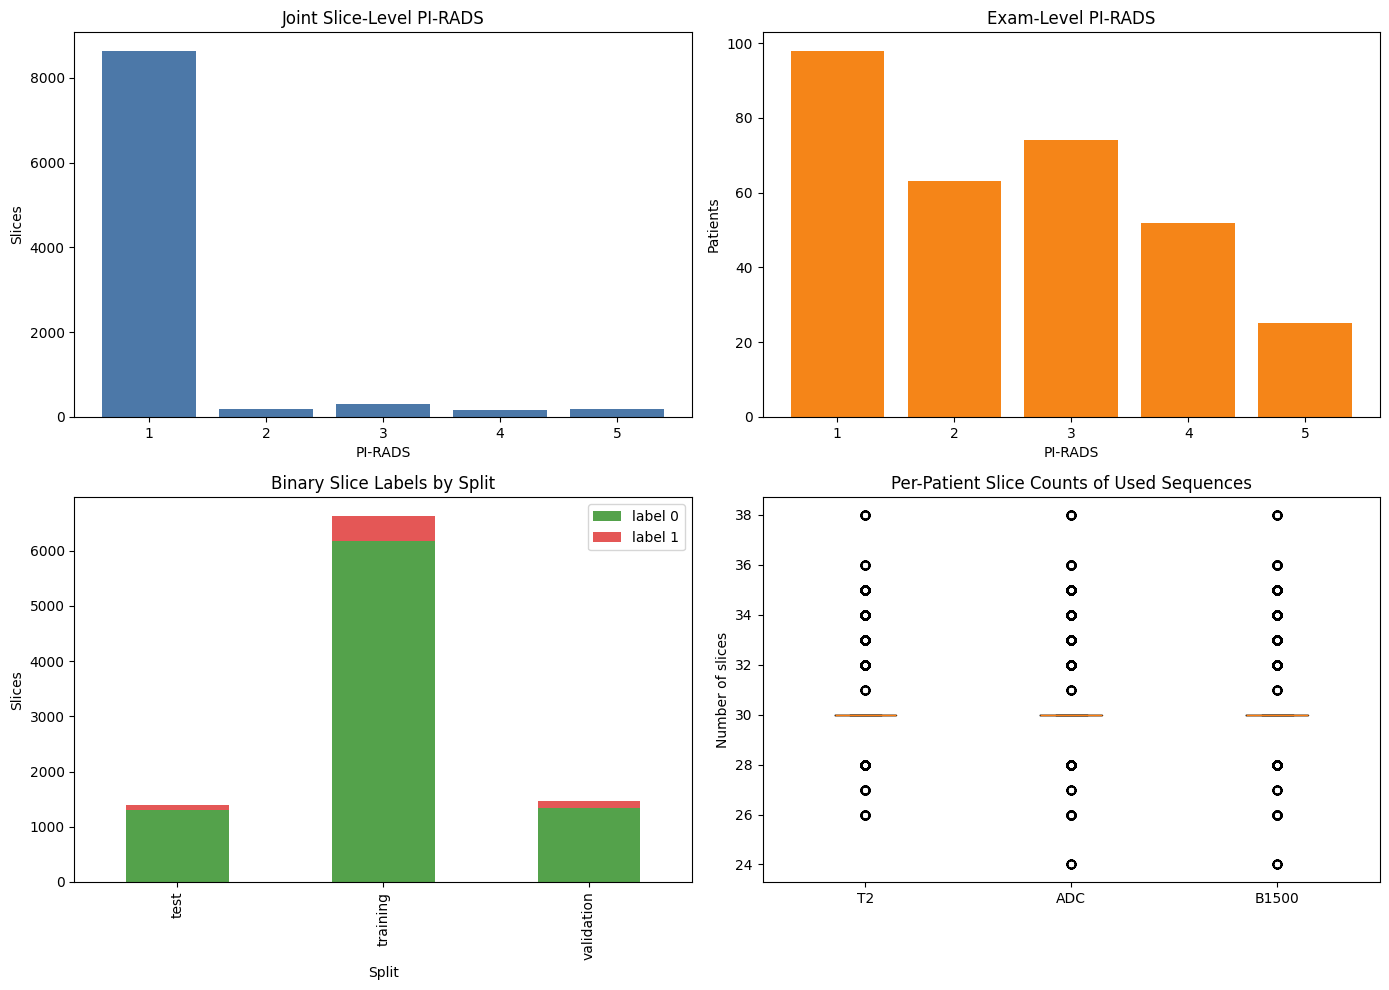

What is what:
- T2 slice labels and DWI slice labels are joined on patient and slice index.
- joint_pirads = max(T2 PIRADS, DWI PIRADS).
- exam_level stays available as a patient-level label for later analysis.


In [20]:
# These quick plots explain the class balance and the structural coverage before modelling.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

joint_counts = matched_slice_table['joint_pirads'].value_counts().sort_index()
axes[0, 0].bar(joint_counts.index.astype(str), joint_counts.values, color='#4C78A8')
axes[0, 0].set_title('Joint Slice-Level PI-RADS')
axes[0, 0].set_xlabel('PI-RADS')
axes[0, 0].set_ylabel('Slices')

exam_counts = volume_exam_labels['exam_level'].value_counts().sort_index()
axes[0, 1].bar(exam_counts.index.astype(str), exam_counts.values, color='#F58518')
axes[0, 1].set_title('Exam-Level PI-RADS')
axes[0, 1].set_xlabel('PI-RADS')
axes[0, 1].set_ylabel('Patients')

split_counts = matched_slice_table.groupby(['data_split', 'target_binary']).size().unstack(fill_value=0)
split_counts.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#54A24B', '#E45756'])
axes[1, 0].set_title('Binary Slice Labels by Split')
axes[1, 0].set_xlabel('Split')
axes[1, 0].set_ylabel('Slices')
axes[1, 0].legend(['label 0', 'label 1'])

counts_df = matched_slice_table[['AX_T2', 'AX_DIFFUSION_ADC', 'AX_DIFFUSION_CALC_BVAL']].rename(columns={
    'AX_T2': 'T2',
    'AX_DIFFUSION_ADC': 'ADC',
    'AX_DIFFUSION_CALC_BVAL': 'B1500',
})
axes[1, 1].boxplot([counts_df[c] for c in counts_df.columns], tick_labels=counts_df.columns)
axes[1, 1].set_title('Per-Patient Slice Counts of Used Sequences')
axes[1, 1].set_ylabel('Number of slices')

plt.tight_layout()
plt.show()

print('What is what:')
print('- T2 slice labels and DWI slice labels are joined on patient and slice index.')
print('- joint_pirads = max(T2 PIRADS, DWI PIRADS).')
print('- exam_level stays available as a patient-level label for later analysis.')





### Result Explanation: Dataset Summary Plots

These plots are a quick health check before training.

- **Joint Slice-Level PI-RADS** shows how many slices fall into each PI-RADS score.
- **Exam-Level PI-RADS** shows patient-level label balance.
- **Binary Slice Labels by Split** shows how lower-risk and higher-risk slices are distributed across train/validation/test splits.
- **Per-Patient Slice Counts** checks whether T2, ADC, and B1500 have enough matching slices.

If one class dominates heavily, accuracy can look misleading. That is why the notebook also tracks balanced accuracy and macro AUC later.



### Cell Explainer: Image Loading And Preprocessing

This section turns DICOM image slices into model-ready arrays.

What happens inside:

1. Find the matching patient/sequence folder.
2. Read one DICOM slice.
3. Apply DICOM rescale metadata if available.
4. Crop the central part of the image to reduce empty background.
5. Normalize image brightness using percentiles.
6. Resize the image to `128 x 128`.
7. Stack three views into one model input:

```text
T2 + ADC + B1500
```

Expected output: one visual sanity check showing the three channels for one sample slice.



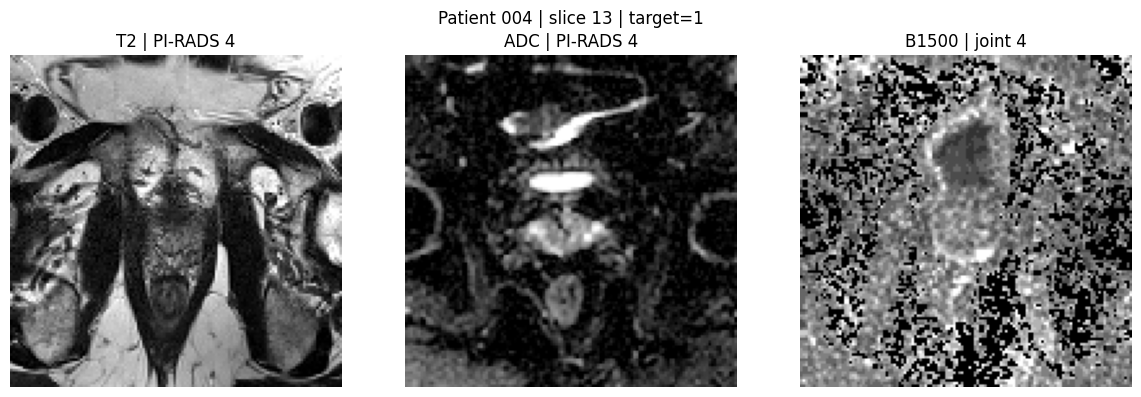

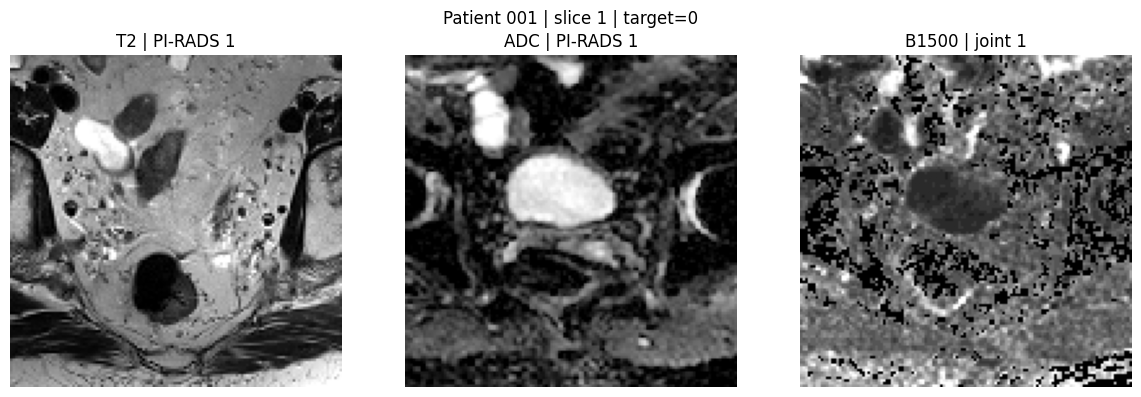

In [21]:
@lru_cache(maxsize=4096)
def get_series_files(patient_id: str, sequence_name: str) -> tuple[Path, ...]:
    # Cache file discovery because the same patient/sequence is reused across many slices.
    series_dir = DICOMS_ROOT / patient_id / sequence_name
    files = tuple(list_visible_files(series_dir))
    if not files:
        raise FileNotFoundError(f'No files found for {patient_id}/{sequence_name}')
    return files


@lru_cache(maxsize=8192)
def read_dicom(file_path: str):
    # Cache DICOM reads to reduce repeated I/O during training and visualization.
    return pydicom.dcmread(file_path, force=True)


def load_slice(patient_id: str, sequence_name: str, slice_zero_based: int) -> np.ndarray:
    # Read one image slice and apply DICOM rescale terms if present.
    files = get_series_files(patient_id, sequence_name)
    if slice_zero_based < 0 or slice_zero_based >= len(files):
        raise IndexError(f'Slice {slice_zero_based} out of bounds for {patient_id}/{sequence_name}')
    file_path = files[slice_zero_based]
    ds = read_dicom(str(file_path))
    try:
        image = ds.pixel_array.astype(np.float32)
    except RuntimeError as exc:
        ts = getattr(getattr(ds, 'file_meta', None), 'TransferSyntaxUID', 'unknown')
        raise RuntimeError(
            f'Unable to decode pixel data for {file_path} with transfer syntax {ts}. '
            + 'Install a DICOM decoder plugin such as '\
            + f"{sys.executable} -m pip install pylibjpeg pylibjpeg-libjpeg "
            + 'or '\
            + f"{sys.executable} -m pip install gdcm"
        ) from exc
    slope = float(getattr(ds, 'RescaleSlope', 1.0) or 1.0)
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0) or 0.0)
    return image * slope + intercept


def normalize_image(image: np.ndarray, q_low: float = 1.0, q_high: float = 99.0) -> np.ndarray:
    # Percentile clipping gives a stable display/training range without being too sensitive to outliers.
    lo, hi = np.percentile(image, [q_low, q_high])
    if hi <= lo:
        lo, hi = float(image.min()), float(image.max())
    if hi <= lo:
        return np.zeros_like(image, dtype=np.float32)
    image = np.clip(image, lo, hi)
    return ((image - lo) / (hi - lo)).astype(np.float32)


def center_crop(image: np.ndarray, fraction: float = 0.88) -> np.ndarray:
    # Prostate occupies the central field of view, so a center crop reduces empty background.
    h, w = image.shape[:2]
    new_h = max(1, int(h * fraction))
    new_w = max(1, int(w * fraction))
    top = (h - new_h) // 2
    left = (w - new_w) // 2
    return image[top:top + new_h, left:left + new_w]


def resize_nn(image: np.ndarray, size: tuple[int, int] = (128, 128)) -> np.ndarray:
    # Keep resizing lightweight and dependency-free for notebook portability.
    target_h, target_w = size
    y_idx = np.linspace(0, image.shape[0] - 1, target_h).astype(int)
    x_idx = np.linspace(0, image.shape[1] - 1, target_w).astype(int)
    return image[np.ix_(y_idx, x_idx)].astype(np.float32)


def build_triplet(patient_id: str, slice_zero_based: int, size: tuple[int, int] = (128, 128)) -> np.ndarray:
    # Build the 3-channel image stack that the VAE sees for one matched slice.
    channels = []
    for seq in ['AX_T2', 'AX_DIFFUSION_ADC', 'AX_DIFFUSION_CALC_BVAL']:
        image = load_slice(patient_id, seq, slice_zero_based)
        image = normalize_image(center_crop(image))
        image = resize_nn(image, size=size)
        channels.append(image)
    return np.stack(channels, axis=0).astype(np.float32)


def show_triplet(row: pd.Series):
    # Visual sanity check: matched channels plus their labels for one slice.
    triplet = build_triplet(row['patient_id'], int(row['slice_zero_based']))
    titles = [
        f"T2 | PI-RADS {row['t2_pirads']}",
        f"ADC | PI-RADS {row['dwi_pirads']}",
        f"B1500 | joint {row['joint_pirads']}",
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i in range(3):
        axes[i].imshow(triplet[i], cmap='gray')
        axes[i].set_title(titles[i])
        axes[i].axis('off')
    fig.suptitle(f"Patient {row['patient_id']} | slice {int(row['slice'])} | target={int(row['target_binary'])}")
    plt.tight_layout()
    plt.show()

sample_pos = matched_slice_table.loc[matched_slice_table['target_binary'] == 1].iloc[0]
sample_neg = matched_slice_table.loc[matched_slice_table['target_binary'] == 0].iloc[0]
show_triplet(sample_pos)
show_triplet(sample_neg)





## 2. Slice Dataset And Model Training

Each training example is one matched slice triplet:

- channel 1: `AX_T2`,
- channel 2: `AX_DIFFUSION_ADC`,
- channel 3: `AX_DIFFUSION_CALC_BVAL` / B1500.

The model learns from the image bundle and predicts a PI-RADS class from 1 to 5.



### Cell Explainer: Dataset, Model, And Loss

This cell defines how one training item is returned to PyTorch.

For each row in the table:

```text
input  = one 3-channel MRI slice bundle
label  = PI-RADS class index from 0 to 4
```

The model itself is imported from `src/prostate_pirads_model.py`. It is a VAE-style model: it compresses the image, reconstructs it, and predicts PI-RADS from the compressed representation.



In [22]:
class FastMRIProstateSliceDataset(Dataset):
    # Each item is one matched T2/ADC/B1500 slice triplet plus a five-class PI-RADS label.
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True).copy()

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        x = build_triplet(row['patient_id'], int(row['slice_zero_based']))
        y = np.int64(row['target_class'])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

print('Five-class PI-RADS dataset, model, and loss are ready.')





Five-class PI-RADS dataset, model, and loss are ready.


### Cell Explainer: Patient-Level Train/Validation/Test Split

This cell separates patients into train, validation, and test groups.

Important detail: the split is done by **patient**, not by individual slice. This prevents leakage. Without patient-level splitting, one slice from a patient could appear in training while another similar slice from the same patient appears in testing.

Expected output:

- number of train, validation, and test slices,
- PI-RADS class counts,
- class weights used to handle imbalance,
- number of model parameters.



In [23]:
# Split by patient rather than by slice so the model never sees the same patient's anatomy in multiple splits.
all_patients = matched_slice_table[['patient_id']].drop_duplicates().sort_values('patient_id')
patient_meta = matched_slice_table.groupby('patient_id')['target_class'].max().reset_index()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_val_idx, test_idx = next(splitter.split(patient_meta[['target_class']], patient_meta['target_class'], groups=patient_meta['patient_id']))
train_val_patients = patient_meta.iloc[train_val_idx]['patient_id']
test_patients = patient_meta.iloc[test_idx]['patient_id']

train_val_df = matched_slice_table[matched_slice_table['patient_id'].isin(train_val_patients)].copy()
test_df = matched_slice_table[matched_slice_table['patient_id'].isin(test_patients)].copy()

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(splitter2.split(train_val_df[['target_class']], train_val_df['target_class'], groups=train_val_df['patient_id']))
train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

# Subsample each split so the notebook remains lightweight enough for exploratory runs on a laptop.
MAX_TRAIN = 3000
MAX_VAL = 1000
MAX_TEST = 1000
train_df = train_df.sample(min(len(train_df), MAX_TRAIN), random_state=42)
val_df = val_df.sample(min(len(val_df), MAX_VAL), random_state=42)
test_df = test_df.sample(min(len(test_df), MAX_TEST), random_state=42)

class_counts = train_df['target_class'].value_counts().reindex(range(5), fill_value=0).sort_index()
class_weights_np = (class_counts.sum() / (5 * class_counts.clip(lower=1))).to_numpy(dtype=np.float32)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

print('Train slices:', len(train_df), '| PI-RADS counts:', class_counts.to_dict())
print('Val slices  :', len(val_df), '| PI-RADS counts:', val_df['target_class'].value_counts().reindex(range(5), fill_value=0).sort_index().to_dict())
print('Test slices :', len(test_df), '| PI-RADS counts:', test_df['target_class'].value_counts().reindex(range(5), fill_value=0).sort_index().to_dict())
print('Class weights:', {PIRADS_CLASS_NAMES[i]: round(float(w), 3) for i, w in enumerate(class_weights_np)})

train_loader = DataLoader(FastMRIProstateSliceDataset(train_df), batch_size=16, shuffle=True)
val_loader = DataLoader(FastMRIProstateSliceDataset(val_df), batch_size=16, shuffle=False)
test_loader = DataLoader(FastMRIProstateSliceDataset(test_df), batch_size=16, shuffle=False)

model = PhysicsAwareSliceVAE(latent_dim=32, input_size=128, num_classes=5).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print('Model parameters:', sum(p.numel() for p in model.parameters()))





Train slices: 3000 | PI-RADS counts: {0: 2725, 1: 62, 2: 90, 3: 52, 4: 71}
Val slices  : 1000 | PI-RADS counts: {0: 921, 1: 17, 2: 33, 3: 19, 4: 10}
Test slices : 1000 | PI-RADS counts: {0: 925, 1: 12, 2: 32, 3: 19, 4: 12}
Class weights: {'PI-RADS 1': 0.22, 'PI-RADS 2': 9.677, 'PI-RADS 3': 6.667, 'PI-RADS 4': 11.538, 'PI-RADS 5': 8.451}
Model parameters: 1143080


### Cell Explainer: Training Loop

This cell defines `run_epoch(...)`, then trains the model.

During each epoch, the model sees every slice in the sampled training set once. For each batch, it computes:

- reconstruction loss: can the model rebuild the MRI slice?
- KL loss: does the compressed latent space stay smooth?
- classification loss: does it predict the correct PI-RADS class?
- ADC/B1500 consistency loss: do the diffusion-related reconstructions stay aligned?

Expected output: one row per epoch with training loss, validation loss, and AUC values.



In [24]:
def safe_multiclass_auc(targets: np.ndarray, probs: np.ndarray) -> float:
    if len(np.unique(targets)) < 2:
        return np.nan
    try:
        return roc_auc_score(
            targets,
            probs,
            labels=list(range(5)),
            multi_class='ovr',
            average='macro',
        )
    except ValueError:
        return np.nan


def run_epoch(model, loader, optimizer=None):
    # Reuse the same function for both training and evaluation.
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    all_probs, all_targets = [], []
    logs = []

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        recon, mu, logvar, logits, z = model(x)
        loss, loss_parts = physics_aware_vae_loss(
            recon,
            x,
            mu,
            logvar,
            logits,
            y,
            class_weights=CLASS_WEIGHTS,
        )
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += float(loss.detach().cpu())
        logs.append(loss_parts)
        all_probs.append(torch.softmax(logits, dim=1).detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy().ravel())

    probs = np.concatenate(all_probs, axis=0)
    targets = np.concatenate(all_targets).astype(int)
    preds = probs.argmax(axis=1)
    auc = safe_multiclass_auc(targets, probs)
    acc = accuracy_score(targets, preds)
    balanced_acc = balanced_accuracy_score(targets, preds) if len(np.unique(targets)) > 1 else np.nan
    mean_logs = {k: float(np.mean([d[k] for d in logs])) for k in logs[0]}
    return total_loss / max(len(loader), 1), auc, acc, balanced_acc, probs, targets, mean_logs

EPOCHS = 20
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_auc, train_acc, train_bal_acc, _, _, train_logs = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_auc, val_acc, val_bal_acc, _, _, val_logs = run_epoch(model, val_loader, optimizer=None)
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_auc': train_auc,
        'train_acc': train_acc,
        'train_balanced_acc': train_bal_acc,
        'val_loss': val_loss,
        'val_auc': val_auc,
        'val_acc': val_acc,
        'val_balanced_acc': val_bal_acc,
        **{f'train_{k}': v for k, v in train_logs.items()},
        **{f'val_{k}': v for k, v in val_logs.items()},
    })
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_auc={train_auc:.3f} train_acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f} val_auc={val_auc:.3f} val_acc={val_acc:.3f}"
    )

history_df = pd.DataFrame(history)
display(history_df)





Epoch 01 | train_loss=0.8529 train_auc=0.486 train_acc=0.755 | val_loss=0.8193 val_auc=0.417 val_acc=0.921
Epoch 02 | train_loss=0.8301 train_auc=0.496 train_acc=0.908 | val_loss=0.7901 val_auc=0.541 val_acc=0.921
Epoch 03 | train_loss=0.8406 train_auc=0.461 train_acc=0.908 | val_loss=0.7995 val_auc=0.517 val_acc=0.921
Epoch 04 | train_loss=0.8238 train_auc=0.493 train_acc=0.908 | val_loss=0.7962 val_auc=0.561 val_acc=0.921
Epoch 05 | train_loss=0.8297 train_auc=0.492 train_acc=0.908 | val_loss=0.8015 val_auc=0.552 val_acc=0.921
Epoch 06 | train_loss=0.8227 train_auc=0.481 train_acc=0.908 | val_loss=0.7843 val_auc=0.491 val_acc=0.921
Epoch 07 | train_loss=0.8261 train_auc=0.477 train_acc=0.908 | val_loss=0.7950 val_auc=0.467 val_acc=0.921
Epoch 08 | train_loss=0.8272 train_auc=0.465 train_acc=0.908 | val_loss=0.7937 val_auc=0.604 val_acc=0.921
Epoch 09 | train_loss=0.8260 train_auc=0.486 train_acc=0.908 | val_loss=0.8012 val_auc=0.516 val_acc=0.921
Epoch 10 | train_loss=0.8270 train_au

,epoch,train_loss,train_auc,train_acc,train_balanced_acc,val_loss,val_auc,val_acc,val_balanced_acc,train_recon_loss,train_kl_loss,train_cls_loss,train_consistency_loss,val_recon_loss,val_kl_loss,val_cls_loss,val_consistency_loss
0,1,0.852934,0.486397,0.755333,0.208691,0.819260,0.417257,0.921,0.2,0.064468,0.060668,1.575118,0.003003,0.060542,0.011373,1.516501,0.003544
1,2,0.830110,0.495734,0.908333,0.200000,0.790122,0.540857,0.921,0.2,0.058141,0.024814,1.542755,0.003438,0.057027,0.042697,1.464784,0.002764
2,3,0.840583,0.460709,0.908333,0.200000,0.799490,0.517228,0.921,0.2,0.056524,0.017286,1.567164,0.003044,0.056456,0.013696,1.485165,0.003149
3,4,0.823810,0.492654,0.908333,0.200000,0.796167,0.561410,0.921,0.2,0.056090,0.018977,1.534436,0.003125,0.056326,0.010531,1.478971,0.002505
4,5,0.829736,0.491918,0.908333,0.200000,0.801473,0.552246,0.921,0.2,0.056002,0.010093,1.546657,0.003042,0.056602,0.004580,1.489375,0.001384
5,6,0.822688,0.480501,0.908333,0.200000,0.784272,0.491247,0.921,0.2,0.055890,0.007941,1.532834,0.003024,0.056069,0.026850,1.455363,0.002527
6,7,0.826118,0.476746,0.908333,0.200000,0.794972,0.467152,0.921,0.2,0.055904,0.008437,1.539650,0.003044,0.055998,0.005378,1.477238,0.003022
7,8,0.827215,0.464552,0.908333,0.200000,0.793702,0.604282,0.921,0.2,0.055772,0.005146,1.542177,0.003026,0.055976,0.004654,1.474760,0.002996
8,9,0.825974,0.485703,0.908333,0.200000,0.801188,0.515729,0.921,0.2,0.055785,0.004786,1.539674,0.003039,0.056047,0.002113,1.489488,0.003758
9,10,0.826988,0.445080,0.908333,0.200000,0.796731,0.507361,0.921,0.2,0.055816,0.002783,1.541687,0.003002,0.056004,0.002240,1.480822,0.002935


### Result Explanation: Epoch Logs

The epoch log tells us whether the model is learning.

How to read it:

- Falling loss means the model is getting better at the combined objective.
- AUC near `0.5` means classification is close to random guessing.
- Validation AUC can jump around when the validation set is small or class-imbalanced.
- If loss improves but AUC does not, the model may be learning reconstruction more than PI-RADS separation.

For a quick hackathon prototype, a few epochs are enough to prove the pipeline works. For a stronger result, train longer on GPU, use more slices, and save the checkpoint with the best validation AUC.



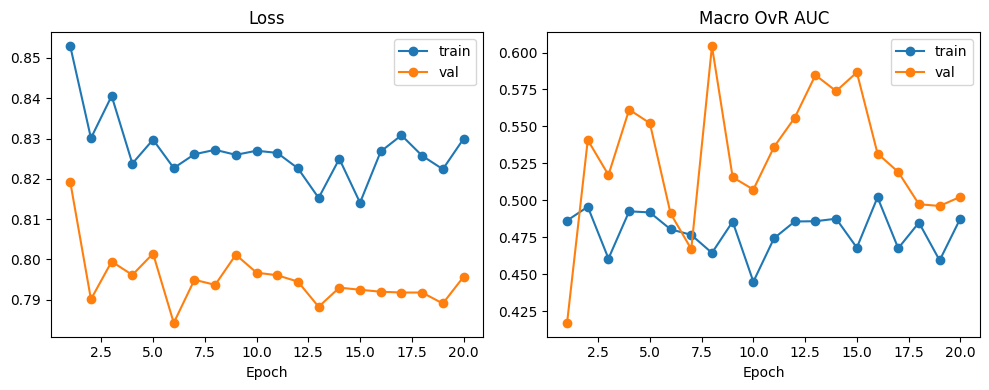

In [25]:
# Training curves help separate reconstruction learning from classification improvement.
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train')
plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['train_auc'], marker='o', label='train')
plt.plot(history_df['epoch'], history_df['val_auc'], marker='o', label='val')
plt.title('Macro OvR AUC')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()





### Result Explanation: Loss And AUC Plot

The left plot shows total loss. The right plot shows macro one-vs-rest AUC across PI-RADS classes.

What to look for:

- **Good sign**: training loss and validation loss generally move downward.
- **Good sign**: validation AUC moves above `0.5` and continues improving.
- **Warning sign**: AUC stays around `0.5`; that means the classifier is not separating PI-RADS classes well yet.
- **Possible but not always bad**: validation loss lower than training loss. This can happen because dropout is active during training but disabled during validation.



Test loss        : 0.803
Test macro OvR AUC: 0.4983
Test accuracy    : 0.925
Test balanced acc: 0.2
Loss components  : {'recon_loss': 0.056564301607154664, 'kl_loss': 0.00041020371293323853, 'cls_loss': 1.492515620731172, 'consistency_loss': 0.0019014825940959984}
              precision    recall  f1-score   support

   PI-RADS 1       0.93      1.00      0.96       925
   PI-RADS 2       0.00      0.00      0.00        12
   PI-RADS 3       0.00      0.00      0.00        32
   PI-RADS 4       0.00      0.00      0.00        19
   PI-RADS 5       0.00      0.00      0.00        12

    accuracy                           0.93      1000
   macro avg       0.18      0.20      0.19      1000
weighted avg       0.86      0.93      0.89      1000



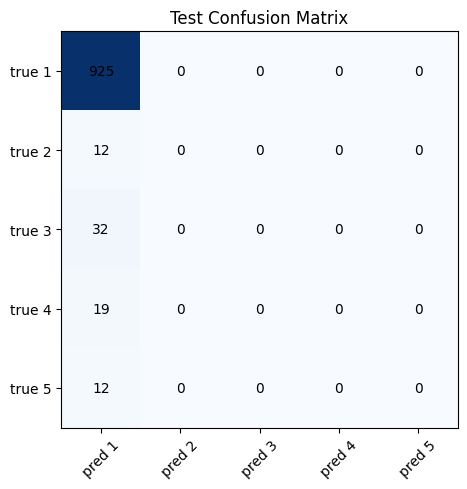

Saved model checkpoint: /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/myworks/prostate-pirads-vae-github/app/model/prostate_pirads_vae.pt
Saved training history : /Users/sabyasachi/Library/CloudStorage/OneDrive-rbionline/golden jubilee application/mission 2025/final college selection/housing/ds_project/rentwise-project/capstone_MSADS/myworks/prostate-pirads-vae-github/app/model/training_history.csv


In [26]:
# Final held-out evaluation on patients the model never saw during training.
test_loss, test_auc, test_acc, test_bal_acc, test_probs, test_targets, test_logs = run_epoch(model, test_loader, optimizer=None)
test_pred = test_probs.argmax(axis=1)
cm = confusion_matrix(test_targets, test_pred, labels=list(range(5)))

print('Test loss        :', round(test_loss, 4))
print('Test macro OvR AUC:', round(float(test_auc), 4) if not np.isnan(test_auc) else 'nan')
print('Test accuracy    :', round(float(test_acc), 4))
print('Test balanced acc:', round(float(test_bal_acc), 4) if not np.isnan(test_bal_acc) else 'nan')
print('Loss components  :', test_logs)
print(classification_report(
    test_targets,
    test_pred,
    labels=list(range(5)),
    target_names=[PIRADS_CLASS_NAMES[i] for i in range(5)],
    zero_division=0,
))

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Test Confusion Matrix')
plt.xticks(range(5), [f'pred {i}' for i in range(1, 6)], rotation=45)
plt.yticks(range(5), [f'true {i}' for i in range(1, 6)])
for i in range(5):
    for j in range(5):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

checkpoint_metrics = {
    'test_loss': float(test_loss),
    'test_auc_macro_ovr': None if np.isnan(test_auc) else float(test_auc),
    'test_accuracy': float(test_acc),
    'test_balanced_accuracy': None if np.isnan(test_bal_acc) else float(test_bal_acc),
    'test_loss_components': test_logs,
}
checkpoint_payload = build_checkpoint_payload(
    model,
    metrics=checkpoint_metrics,
    class_weights=[float(x) for x in CLASS_WEIGHTS.detach().cpu().numpy()],
)
torch.save(checkpoint_payload, PROJECT_MODEL_PATH)
history_df.to_csv(PROJECT_MODEL_PATH.parent / 'training_history.csv', index=False)
print(f'Saved model checkpoint: {PROJECT_MODEL_PATH}')
print(f'Saved training history : {PROJECT_MODEL_PATH.parent / "training_history.csv"}')





### Result Explanation: Held-Out Test Results

This is the most important evaluation cell because the test patients were not used during training.

How to read the outputs:

- **Test accuracy**: simple fraction of correctly predicted slices.
- **Balanced accuracy**: better when classes are imbalanced.
- **Macro OvR AUC**: checks whether the model ranks each PI-RADS class better than random.
- **Confusion matrix**: shows which PI-RADS scores are being confused with which.

For a medical-risk prototype, do not rely on accuracy alone. If the model mostly predicts the common class, accuracy may look acceptable while clinically meaningful separation is weak.



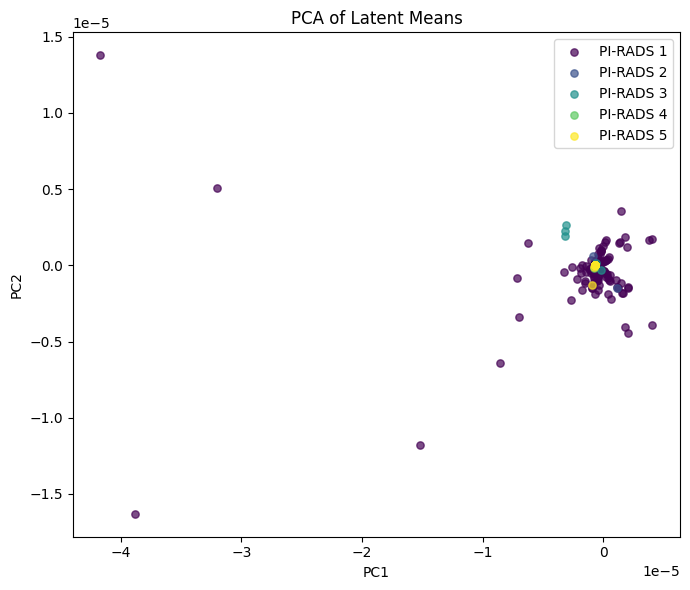

In [27]:
# Project the latent means to 2D to see whether the learned representation separates PI-RADS classes.
model.eval()
all_z, all_y = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        recon, mu, logvar, logits, z = model(x)
        all_z.append(mu.detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy().ravel())

Z = np.concatenate(all_z)
Y = np.concatenate(all_y).astype(int)
coords = PCA(n_components=2, random_state=42).fit_transform(Z)

plt.figure(figsize=(7, 6))
colors = plt.cm.viridis(np.linspace(0, 1, 5))
for label_idx, color in enumerate(colors):
    mask = Y == label_idx
    if mask.any():
        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=28,
            alpha=0.7,
            label=PIRADS_CLASS_NAMES[label_idx],
            c=[color],
        )
plt.title('PCA of Latent Means')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()





### Result Explanation: Latent Space Plot

This plot compresses the model's internal representation down to two dimensions using PCA.

How to read it:

- If PI-RADS classes form visible clusters, the model has learned some class structure.
- If all colors are mixed together, the model's latent space is not clearly separating risk levels.
- Some overlap is expected because neighboring PI-RADS scores can be clinically subtle.



## 3. Project Workflow

The app workflow is summarized below.

![Workflow: from prostate MRI slice to PI-RADS prediction](../assets/workflow.png)

